# Анализ увольнения сотрудников (IBM HR Analytics)

## 1. Загрузка данных

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [21]:
# Загрузка датасета
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Базовая предобработка
df = df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'])
df['Attrition'] = df['Attrition'].map({'Yes' : 1, 'No' : 0})

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


## 2. Обучение общей модели классификации

In [22]:
# Кодирование категориальных признаков
df_model = df.copy()
le = LabelEncoder()
cat_cols = df_model.select_dtypes(include=['object']).columns
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])
    
X = df_model.drop(columns=['Attrition'])
Y = df_model['Attrition']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=42, stratify=Y)


rf_all = RandomForestClassifier(n_estimators=100, random_state=42)
rf_all.fit(X_train, Y_train)


Y_pred = rf_all.predict(X_test)


print(f"Accuracy на тестовой выборке: {accuracy_score(Y_test, Y_pred):.4f}")
print("\nОтчет по классификации:")
print(classification_report(Y_test, Y_pred))


Accuracy на тестовой выборке: 0.8435

Отчет по классификации:
              precision    recall  f1-score   support

           0       0.86      0.98      0.91       247
           1       0.55      0.13      0.21        47

    accuracy                           0.84       294
   macro avg       0.70      0.55      0.56       294
weighted avg       0.81      0.84      0.80       294



## 3. Определим топ-5 важных признаков для каждого уровня образования (Education) и сравним их

In [23]:
def get_top_features(model, feature_names, n=5):
    feat_imp = pd.Series(model.feature_importances_, index=feature_names)
    feat_imp = feat_imp.sort_values(ascending=False)
    return list(feat_imp.head(n).index)

In [24]:
education_levels = sorted(df['Education'].unique())
top_features_by_edu = {}

for edu in education_levels:
    subset = df_model[df_model['Education'] == edu]
    
    X_edu = subset.drop(columns=['Attrition'])
    Y_edu = subset['Attrition']
    
    rf_edu = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_edu.fit(X_edu, Y_edu)
    
    top_features_by_edu[edu] = get_top_features(rf_edu, X_edu.columns, n=5)


print("Топ-5 признаков для каждого уровня образования:")
for edu, features in top_features_by_edu.items():
    print(f"Уровень {edu}: {', '.join(features)}")

Топ-5 признаков для каждого уровня образования:
Уровень 1: Age, MonthlyIncome, TotalWorkingYears, DailyRate, YearsAtCompany
Уровень 2: MonthlyIncome, HourlyRate, DistanceFromHome, MonthlyRate, DailyRate
Уровень 3: MonthlyIncome, TotalWorkingYears, MonthlyRate, Age, DailyRate
Уровень 4: Age, MonthlyIncome, TotalWorkingYears, HourlyRate, OverTime
Уровень 5: DailyRate, HourlyRate, TotalWorkingYears, EducationField, Age


## 4. Проанализируем насколько критичен WorkLifeBalance для увольнения

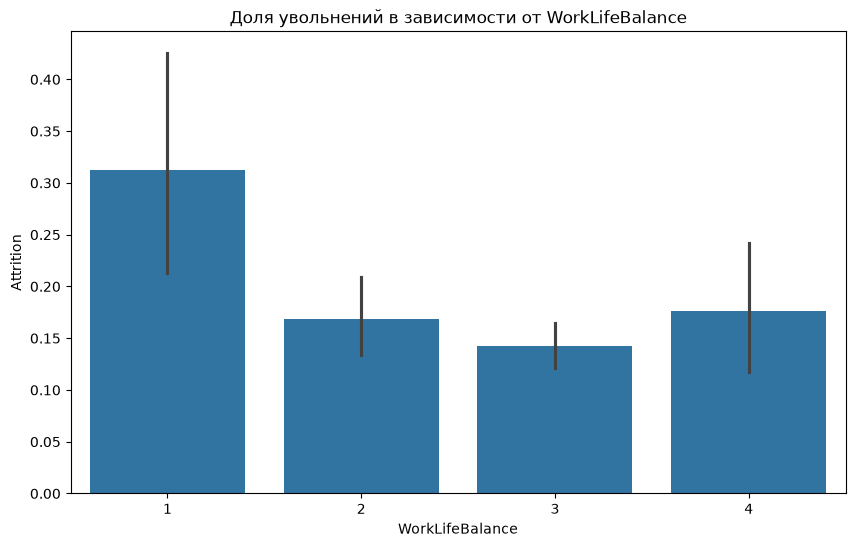

Доля увольнений по WorkLifeBalance (%): 
WorkLifeBalance
1    31.2
2    16.9
3    14.2
4    17.6
Name: Attrition, dtype: float64

Численность групп: 
WorkLifeBalance
1     80
2    344
3    893
4    153
Name: count, dtype: int64

WorkLifeBalance в общей модели: место 17 из 30, важность 0.0277


In [25]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='WorkLifeBalance', y='Attrition')
plt.title('Доля увольнений в зависимости от WorkLifeBalance')
plt.show()


print('Доля увольнений по WorkLifeBalance (%): ')
print((df.groupby('WorkLifeBalance')['Attrition'].mean() * 100).round(1))
print('\nЧисленность групп: ')
print(df['WorkLifeBalance'].value_counts().sort_index())


# Важность в общей модели
importances_all = pd.Series(rf_all.feature_importances_, index=X.columns).sort_values(ascending=False)
rank = list(importances_all.index).index('WorkLifeBalance') + 1
print(f'\nWorkLifeBalance в общей модели: место {rank} из {len(importances_all)}, '
      f'важность {importances_all["WorkLifeBalance"]:.4f}')


## 5. Сравним факторы увольнения для сотрудников с разным перформансом

In [27]:
perf_ratings = sorted(df['PerformanceRating'].unique())
top_gen = get_top_features(rf_all, X.columns, n=5)
print(f'Топ-5 общей модели: {', '.join(top_gen)}\n')


for perf in perf_ratings:
    subset = df_model[df_model['PerformanceRating'] == perf]
    X_perf = subset.drop(columns=['Attrition'])
    Y_perf = subset['Attrition']
    
    
    rf_perf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_perf.fit(X_perf, Y_perf)
    
    top_p = get_top_features(rf_perf, X_perf.columns, n=5)
    print(f'Топ-5 для PerformanceRating {perf}: {', '.join(top_p)}')

Топ-5 общей модели: MonthlyIncome, Age, TotalWorkingYears, HourlyRate, DailyRate

Топ-5 для PerformanceRating 3: MonthlyIncome, Age, DailyRate, TotalWorkingYears, MonthlyRate
Топ-5 для PerformanceRating 4: MonthlyIncome, TotalWorkingYears, OverTime, MaritalStatus, JobSatisfaction


## 6. Влияние сверхурочной работы (OverTime) на желание уйти из компании

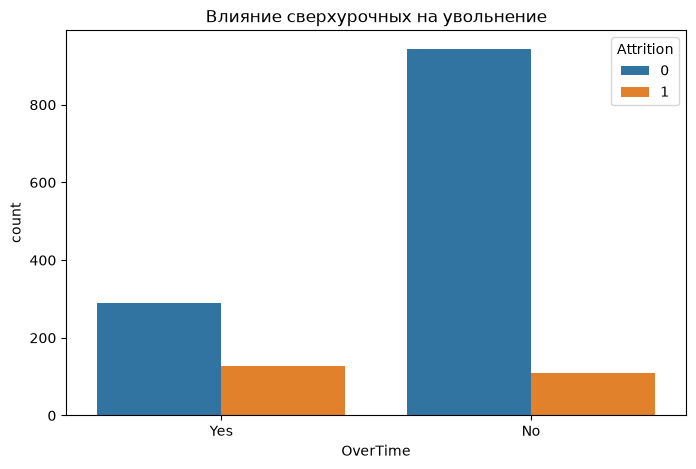

Процент увольнений при наличии OverTime: 30.53%
Процент увольнений без OverTime: 10.44%


In [35]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='OverTime', hue='Attrition')
plt.title('Влияние сверхурочных на увольнение')
plt.show()

overtime_attrition = df.groupby('OverTime')['Attrition'].mean()
print(f"Процент увольнений при наличии OverTime: {overtime_attrition['Yes']*100:.2f}%")
print(f"Процент увольнений без OverTime: {overtime_attrition['No']*100:.2f}%")

## 7. Посмотрим на распределение ежемесячного дохода в зависимости от стажа для тех, кто ушел и кто остался

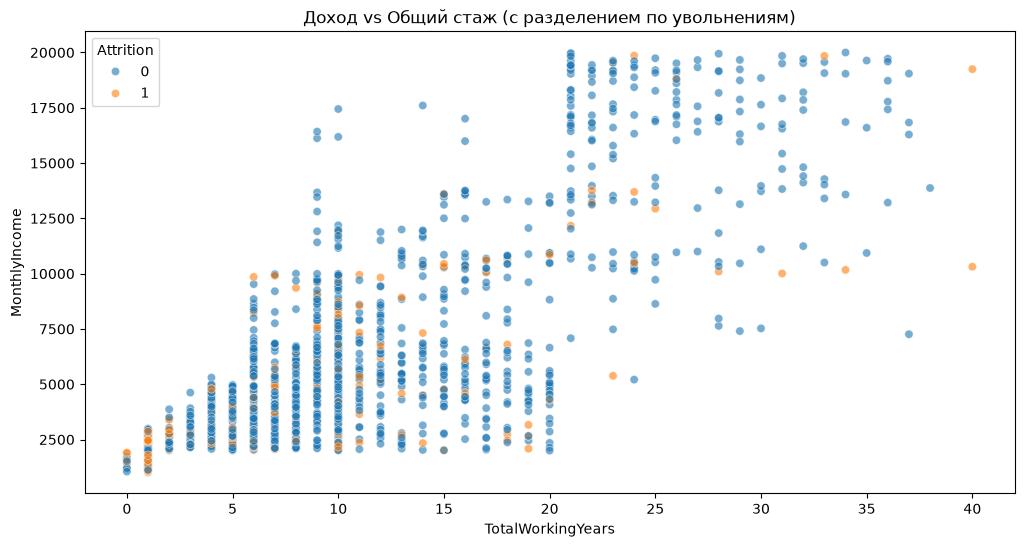

In [38]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='TotalWorkingYears', y='MonthlyIncome', hue='Attrition', alpha=0.6)
plt.title('Доход vs Общий стаж (с разделением по увольнениям)')
plt.show()

## 8. Проверим, является ли долгое время в пути до работы (DistanceFromHome) фактором риска ухода

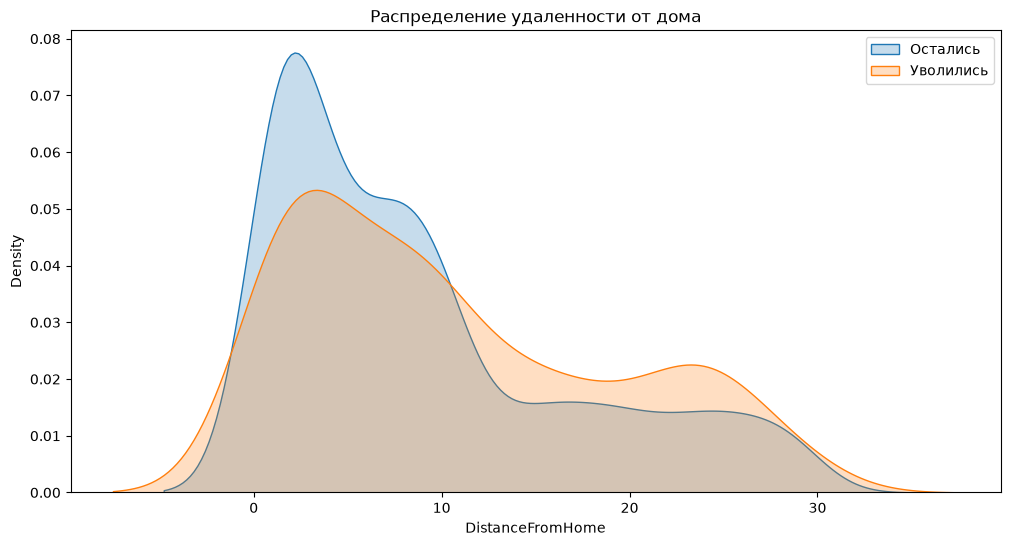

In [39]:
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df[df['Attrition'] == 0], x='DistanceFromHome', label='Остались', fill=True)
sns.kdeplot(data=df[df['Attrition'] == 1], x='DistanceFromHome', label='Уволились', fill=True)
plt.title('Распределение удаленности от дома')
plt.legend()
plt.show()